<a href="https://colab.research.google.com/github/LeandroD-240/churn_retention/blob/main/churn_and_retetion_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Churn Prediction and Retention ROI Simulator

## Business Understanding

### Company Context

**VoxTel** is a mid-sized regional telecommunications provider serving approximately **500,000 postpaid subscribers** across three product lines: mobile plans, home broadband, and bundled OTT streaming packages. Operating in a saturated and highly competitive market, VoxTel has seen its monthly churn rate climb to **3.2%** over the last four quarters — more than double the industry benchmark of 1.5%.

Each churned subscriber represents not only lost Monthly Recurring Revenue (MRR) but also the sunk cost of customer acquisition (CAC), estimated at \$180 per subscriber. At its current trajectory, the business is projected to lose an estimated **$28M in annualized revenue** if the churn trend is not reversed.

The leadership team has named customer retention a Tier-1 strategic priority. However, current retention campaigns are applied broadly and without targeting, resulting in a high cost-per-save and significant budget waste on customers who were never going to churn in the first place.

---

### Frame the Problem

VoxTel has been experiencing sustained churn across several consecutive quarters. The core challenge is twofold:

1.  **Identify** which customers are likely to churn before they do.
2.  **Act** on those predictions with the right retention strategy at the right time.

The company currently lacks a systematic, data-driven mechanism to prioritize which customers to target, leading to inefficient retention campaigns deployed indiscriminately across the entire subscriber base.

---

### The Root Cause (5 Why's)

1.  **Why are customers churning?** Because of unidentified and varying reasons that the company often cannot acknowledge in time — such as competitive offers, service dissatisfaction, billing disputes, or life events.

2.  **Why can't the company acknowledge these reasons?** Because it lacks the tools to recognize patterns in customer behavior that are predictive of churn before it actually happens.

3.  **Why can't the company catch these patterns?** Because it has no automated technique or system that calls it to action. The company can offer discounts, place calls, or provide upgrades — but applying these strategies to every customer is prohibitively expensive.

4.  **Why is it expensive to implement these strategies for every customer?** Because the company cannot differentiate customers who are likely to churn from those who are not, resulting in wasted spend on already-loyal subscribers.

**The root cause**, therefore, is the **absence of a predictive system** capable of identifying at-risk customers and enabling targeted, cost-efficient retention actions before churn occurs.

---

### KPIs

#### 1. Customer Lifetime Value (CLV)

**Formula:**

```
CLV = (ARPU × Gross Margin %) / Monthly Churn Rate
```

Where:
-   **ARPU** = Average Revenue Per User per month (e.g., $45)
-   **Gross Margin %** = Revenue minus variable service costs, expressed as a percentage (e.g., 60%)
-   **Monthly Churn Rate** = Fraction of active customers lost in a given month (e.g., 0.032)

**Example:** CLV = (\$45 × 0.60) / 0.032 = **$843.75 per customer**

**Explanation:** CLV quantifies the total expected net revenue a customer generates over the entire duration of their relationship with the company. It serves as the anchor for every retention investment decision — it defines the upper bound of what the company should rationally spend to save a single customer. In this project, CLV is used to **prioritize intervention targets**: retaining a high-CLV subscriber justifies a costlier intervention (e.g., a personal retention call with a premium upgrade), while a low-CLV subscriber may only warrant a low-cost automated campaign.

---

#### 2. Projected Savings (Retention ROI)

**Formula:**

```
Projected Savings = (TP × Rc × CLV) − (N_contacted × C_intervention)
```

Where:
-   **TP** = True Positives: customers correctly identified as at-risk who were contacted
-   **Rc** = Retention Conversion Rate: fraction of contacted at-risk customers who are successfully retained (e.g., 25%)
-   **CLV** = Customer Lifetime Value (see above)
-   **N_contacted** = Total customers contacted = TP + FP (True Positives + False Positives)
-   **C_intervention** = Average cost per retention action (e.g., $15: agent time + offer cost)

**Example:** With TP = 1,200, Rc = 0.25, CLV = 843, N_contacted = 1,500, C_intervention = \$15:
-   Revenue saved = 1,200 × 0.25 × \$843 = **\$252,900**
-   Campaign cost = 1,500 × \$15 = **\$22,500**
-   **Net Projected Savings = $230,400 per campaign cycle**

**Explanation:** Projected Savings directly translates the model's predictive accuracy into business value. It captures the financial benefit of acting on the model's output while accounting for the full cost of the retention campaign. The better the model's **precision** (fewer False Positives), the lower the unnecessary intervention cost and the higher the net ROI. This KPI is the primary metric used to evaluate not just model performance in isolation, but the end-to-end **business performance** of the entire retention pipeline.

---

#### 3. Revenue at Risk

**Formula:**

```
Revenue at Risk = Σ [ P(churn_i) × CLV_i ]   for all i in the active subscriber base
```

Where:
-   **P(churn_i)** = Predicted churn probability for customer *i* (model output)
-   **CLV_i** = Estimated Lifetime Value for customer *i*
-   The sum runs across all N active subscribers

**Example:** A segment of 10,000 customers with an average P(churn) = 0.40 and an average CLV of \$843 yields a Revenue at Risk of **$3.37M**.

**Explanation:** Revenue at Risk is a metric that aggregates expected revenue exposure across the entire subscriber base, weighted by each customer's individual churn probability and economic value. Unlike a binary churn flag, this measure uses the raw probability output of the model to express financial exposure as a continuous, monetized signal. It gives the **C-suite, Finance, and Risk teams** a single number summarizing how much revenue is currently "at risk" — enabling strategic decisions on how aggressively to deploy retention budgets. This KPI is updated on a rolling monthly basis as the model rescores the full subscriber base.

---

### Business Levers

Once at-risk customers are identified by the model, the following retention interventions can be deployed. Each lever is calibrated to the customer's **predicted risk tier** (Low: < 30%, Medium: 30–60%, High: > 60%) and estimated CLV, ensuring that intervention cost is proportional to the value at stake:

| Lever | Target Segment |
|---|---|
| Targeted Discount | High risk, price-sensitive, mid CLV |
| Proactive Retention Call | High CLV, high risk |
| Service Upgrade | Usage-driven churners |
| Loyalty Program Enrollment | Long-tenure, mid-risk |
| Contract Lock-In Incentive | Month-to-month, moderate risk |
| Personalized Re-engagement | Low-to-mid risk, high-volume |
| Priority Technical Support | Repeated service complaints |

The model's churn probability score will be used to **segment customers into risk tiers**, and each tier will be assigned the appropriate lever (or combination of levers) based on cost-effectiveness and expected conversion rate.

---

### Prediction Horizon and Operational Timing

The model does not predict whether a customer will *eventually* churn at some point in the future. It predicts whether a customer is likely to churn **within the next 2 months from the scoring date**.

This distinction is intentional and has direct operational consequences. Retention campaigns are not instantaneous. Between the moment the model flags a customer as at-risk and the moment that customer actually receives an intervention, VoxTel's teams must complete several sequential steps:

| Operational Step | Estimated Time Required |
|---|---|
| Budget approval from Finance / Marketing leadership | 3–5 business days |
| Campaign design: offer selection, channel, creative assets | 5–7 business days |
| Execution: agent scheduling, SMS/email deployment, call queues | 3–5 business days |
| Customer response window: time for the subscriber to evaluate the offer | 7–14 days |
| **Total minimum lead time** | **~3 to 4 weeks** |

This means that if VoxTel's operational teams do not act on the model's output **within the first 2–3 weeks of each monthly scoring cycle**, they risk a compounding failure: the model correctly identified an at-risk customer, a budget was allocated, a campaign was planned — but the customer canceled before the intervention ever reached them. This is a **silent operational failure**: it does not register as a model error, yet it still costs the business the full CLV of that subscriber.

#### The Contractual Commitment

The 2-month prediction horizon represents a **service-level agreement between the Data Science team and VoxTel's operational units**:

-   **The DS team commits** to delivering a scored, risk-tiered customer list at the start of each monthly cycle, with sufficient lead time for teams to act.
-   **Operations, Marketing, and Customer Success commit** to launching campaigns within the first 2–3 weeks of receiving that list — before the churn window closes.

If this operational commitment is not honored, the model's accuracy becomes irrelevant. Early identification only creates value when it is followed by timely action.

---

### Is This a Data Science Problem?

Yes. The project satisfies each of the qualifying criteria for a Machine Learning intervention:

| Criterion | ✓ |
|---|---|
| Enough data? | Yes — 24+ months, ~5,000 labeled churn events |
| Complex pattern? | Yes — non-linear mix of behavioral & financial signals |
| Better prediction → better decision? | Yes — enables targeted, not blanket, campaigns |
| Output operationalizable? | Yes — feeds Marketing, Customer Success, Finance |
| Impact measurable? | Yes — via Projected Savings + A/B holdout testing |

---

### Analytical Approach

This project adopts a **predictive, prescriptive, and evaluative** approach across three interconnected layers:

1.  **Predictive layer** — A supervised classification model (evaluated across Logistic Regression, Gradient Boosting or ensemble methods) trained on historical subscriber behavior to produce a churn probability score for each active customer. The prediction target is explicitly defined as **churn within the next 2 months**, establishing the operational window within which retention actions must be executed (see *Prediction Horizon and Operational Timing* above).

2.  **Prescriptive layer** — A decision engine that uses the churn probability score and individual CLV estimate to assign each customer to a risk tier and recommend the optimal retention lever (see Business Levers above).

3.  **Evaluation layer** — A Retention ROI Simulator that quantifies the financial impact of the retention campaign in terms of Projected Savings, modeling the tradeoff between model precision, intervention cost, and revenue retained.

This end-to-end framework ensures the project is not merely a modeling exercise but a complete **business decision support system** aligned with VoxTel's strategic retention objectives.

## Data Understanding

### Dictionary Table

| Field | Type | Signal |
|---|---|---|
| customer_id | Integer | Unique identifier |
| tenure_months | Integer | Short tenure = early dropout risk |
| monthly_charges | Float | High charge + low use = churn risk |
| contract_type | Categorical | Strongest churn predictor |
| num_support_tickets | Integer | Friction/dissatisfaction proxy |
| data_usage_gb | Float | Low/declining use = disengagement |
| has_streaming_addon | Binary | Bundling lowers churn risk |
| last_login_days_ago | Integer | Disengagement signal |
| plan_type | Categorical | Segments retention tier |
| payment_method | Categorical | Electronic = lower churn |
| payment_delay_days | Integer | Financial friction signal |
| clv_estimated | Float | Powers the ROI simulator |
| churned | Binary | Target variable |
| retention_action | Categorical | Added during simulation |

### Samples

| Field | C-00841 | C-01293 |
|---|---|---|
| tenure_months | 6 | 31 |
| monthly_charges | 79.90 | 44.50 |
| contract_type | Month-to-month | One-year |
| num_support_tickets | 4 | 0 |
| data_usage_gb | 1.2 | 18.7 |
| has_streaming_addon | 0 | 1 |
| last_login_days_ago | 38 | 3 |
| plan_type | Standard | Basic |
| payment_method | Credit card | Bank transfer |
| payment_delay_days | 12 | 0 |
| clv_estimated | 479.40 | 1379.50 |
| churned | 1 | 0 |

## Data Preparation and EDA

### Data Collection

In [1]:
# Imports

# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Statistic significance
from scipy.stats import skew, kurtosis, chi2_contingency
from scipy.stats.contingency import association

# Helpers
from itertools import combinations
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Scikit-learn functions
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn import metrics

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
import shap

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Data collection
df = pd.read_csv("voxtel_data.csv")

# Checking
df.head(2)

,customer_id,tenure_months,contract_type,plan_type,monthly_charges,total_charges,payment_method,payment_delay_days,data_usage_gb,has_streaming_addon,num_support_tickets,last_login_days_ago,clv_estimated,churned
0,C-00001,6,Month-to-month,Basic,36.60,219.60,Bank transfer,3,0.62,1,4,62,86.36,1
1,C-00002,46,Two-year,Standard,58.64,2697.44,Credit card,1,3.48,1,1,22,1574.56,0


### Data Cleanup

In [3]:
# Checking duplicates
duplicates = df.duplicated().sum()
print(f"Duplicated rows: {duplicates:.0f}")

Duplicated rows: 0


In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          5000 non-null   object 
 1   tenure_months        5000 non-null   int64  
 2   contract_type        5000 non-null   object 
 3   plan_type            5000 non-null   object 
 4   monthly_charges      5000 non-null   float64
 5   total_charges        5000 non-null   float64
 6   payment_method       5000 non-null   object 
 7   payment_delay_days   5000 non-null   int64  
 8   data_usage_gb        5000 non-null   float64
 9   has_streaming_addon  5000 non-null   int64  
 10  num_support_tickets  5000 non-null   int64  
 11  last_login_days_ago  5000 non-null   int64  
 12  clv_estimated        5000 non-null   float64
 13  churned              5000 non-null   int64  
dtypes: float64(4), int64(6), object(4)
memory usage: 547.0+ KB


In [5]:
# Basic statistics (numeric)
df.describe()

,tenure_months,monthly_charges,total_charges,payment_delay_days,data_usage_gb,has_streaming_addon,num_support_tickets,last_login_days_ago,clv_estimated,churned
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.354200,54.264754,1100.190728,4.889800,8.533682,0.428000,1.082800,18.490800,1205.492232,0.330200
std,15.671779,25.826099,1078.123819,6.955957,10.993258,0.494838,1.271168,27.556563,1250.012444,0.470332
min,1.000000,20.010000,20.050000,0.000000,0.110000,0.000000,0.000000,0.000000,10.020000,0.000000
25%,6.000000,32.605000,288.857500,1.000000,1.587500,0.000000,0.000000,2.000000,131.927500,0.000000
50%,18.000000,51.095000,805.270000,2.000000,4.020000,0.000000,1.000000,7.000000,894.875000,0.000000
75%,31.000000,66.852500,1542.172500,7.000000,11.335000,1.000000,2.000000,23.000000,1802.015000,1.000000
max,72.000000,119.890000,7493.850000,60.000000,90.520000,1.000000,5.000000,339.000000,8103.720000,1.000000


In [6]:
# Skewness and kurtosis on each field
print("Skewness and kurtosis report:")
for column in df.describe().columns:
  print(f"Column: {column} | Skewness: {df[column].skew():.4f} | Kurtosis: {df[column].kurtosis():.4f}")

Skewness and kurtosis report:
Column: tenure_months | Skewness: 0.6348 | Kurtosis: -0.4369
Column: monthly_charges | Skewness: 0.7769 | Kurtosis: -0.2376
Column: total_charges | Skewness: 1.7290 | Kurtosis: 3.7835
Column: payment_delay_days | Skewness: 2.7941 | Kurtosis: 10.7955
Column: data_usage_gb | Skewness: 2.5657 | Kurtosis: 8.9084
Column: has_streaming_addon | Skewness: 0.2911 | Kurtosis: -1.9160
Column: num_support_tickets | Skewness: 1.1026 | Kurtosis: 0.4315
Column: last_login_days_ago | Skewness: 3.3631 | Kurtosis: 18.9437
Column: clv_estimated | Skewness: 1.4809 | Kurtosis: 2.4956
Column: churned | Skewness: 0.7223 | Kurtosis: -1.4788


In [7]:
# Basic statistics (categorical)
df.describe(exclude=np.number)

,customer_id,contract_type,plan_type,payment_method
count,5000,5000,5000,5000
unique,5000,3,3,4
top,C-05000,Month-to-month,Basic,Credit card
freq,1,2500,2025,1756


In [8]:
# Streaming added field (boolean)
df["has_streaming_addon"].value_counts()

,count
has_streaming_addon,
0,2860
1,2140


In [9]:
# Churned field (boolean)
df["churned"].value_counts()

,count
churned,
0,3349
1,1651


### Data Visualization

In [10]:
# Mean feature values by churn
not_churned = df[df["churned"] == 0]
churned = df[df["churned"] == 1]

not_churned = not_churned.describe().loc["50%"]
not_churned.rename("Not churned", inplace=True)

churned = churned.describe().loc["50%"]
churned.rename("Churned", inplace=True)

mean_fields_churn = pd.concat([not_churned, churned], axis=1)
mean_fields_churn

,Not churned,Churned
tenure_months,25.00,7.00
monthly_charges,53.16,46.53
total_charges,1139.25,288.86
payment_delay_days,1.00,6.00
data_usage_gb,6.88,1.48
has_streaming_addon,0.00,0.00
num_support_tickets,0.00,2.00
last_login_days_ago,4.00,37.00
clv_estimated,1438.89,84.37
churned,0.00,1.00


In [11]:
# Brand palette & global style
MAIN   = "#FFDBBB"   # Active / Not churned
ACCENT = "#E55934"   # Churned / Alert
DARK   = "#2D2D2D"   # Titles, axis text
MID    = "#888888"   # Subtitles, secondary text
BG     = "#FFFFFF"   # Figure background
TEXT   = "#2D2D2D"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.edgecolor":    "#CCCCCC",
    "axes.labelcolor":   DARK,
    "xtick.color":       DARK,
    "ytick.color":       DARK,
    "font.family":       "sans-serif",
    "font.size":         11,
    "text.color":        DARK,
    "figure.dpi":        130,
})

LABEL_MAP = {0: "Active", 1: "Churned"}

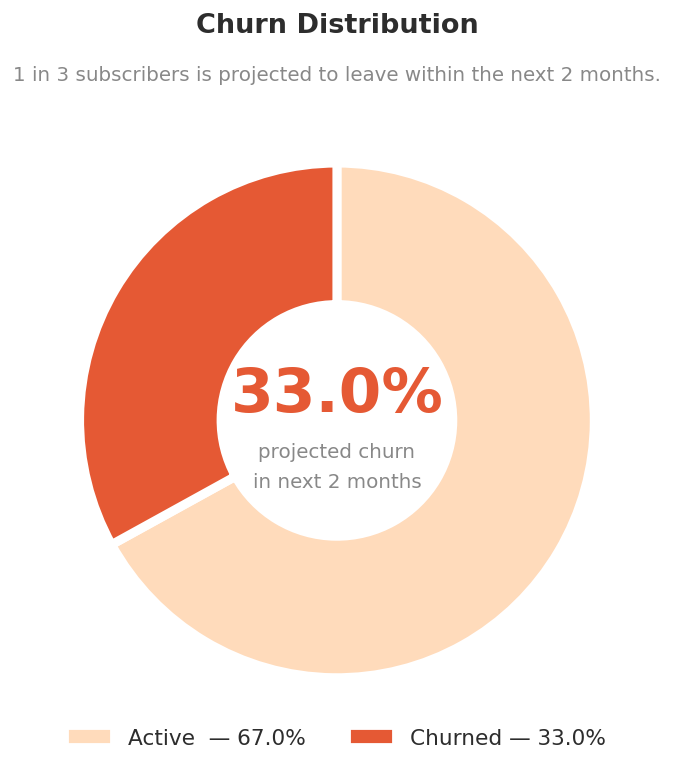

In [12]:
# Churn distribution
churned_rate = df["churned"].mean()
active_rate  = 1 - churned_rate

fig, ax = plt.subplots(figsize=(6, 6))

wedges, _ = ax.pie(
    [active_rate, churned_rate],
    colors=[MAIN, ACCENT],
    startangle=90,
    counterclock=False,
    wedgeprops={"width": 0.55, "edgecolor": BG, "linewidth": 5},
)

# Centre annotation — the number that matters most
ax.text(0,  0.10, f"{churned_rate:.1%}",
        ha="center", va="center",
        fontsize=34, fontweight="bold", color=ACCENT)
ax.text(0, -0.18, "projected churn\nin next 2 months",
        ha="center", va="center",
        fontsize=11, color=MID, linespacing=1.7)

ax.legend(
    handles=[
        mpatches.Patch(fc=MAIN,   ec=BG, label=f"Active  — {active_rate:.1%}"),
        mpatches.Patch(fc=ACCENT, ec=BG, label=f"Churned — {churned_rate:.1%}"),
    ],
    loc="lower center", bbox_to_anchor=(0.5, -0.04),
    ncol=2, frameon=False, fontsize=12,
)

fig.suptitle("Churn Distribution", fontsize=15, fontweight="bold", color=DARK)
ax.set_title("1 in 3 subscribers is projected to leave within the next 2 months.",
             fontsize=11, color=MID, pad=10)

plt.tight_layout()
plt.savefig("plot_01_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Function for barplots
def churn_rate_barh(column, title, subtitle, filename=None):
    stats = (
        df.groupby(column)["churned"]
        .agg(churn_rate="mean", n="count")
        .sort_values("churn_rate", ascending=True)   # top bar = highest risk
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, max(3.5, len(stats) * 1.5)))

    colors = [ACCENT if i == len(stats) - 1 else MAIN
              for i in range(len(stats))]

    bars = ax.barh(
        stats[column], stats["churn_rate"],
        color=colors, edgecolor=BG, height=0.45,
    )

    max_rate = stats["churn_rate"].max()
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(
            bar.get_width() + max_rate * 0.025,
            bar.get_y() + bar.get_height() / 2,
            f"{row['churn_rate']:.1%}   n = {row['n']:,}",
            va="center", ha="left",
            fontsize=11, color=DARK, fontweight="bold",
        )

    ax.set_xlim(0, max_rate * 1.6)
    ax.set_xticks([])
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=12)
    fig.suptitle(title,    fontsize=15, fontweight="bold", color=DARK)
    ax.set_title(subtitle, fontsize=11, color=MID, pad=10)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

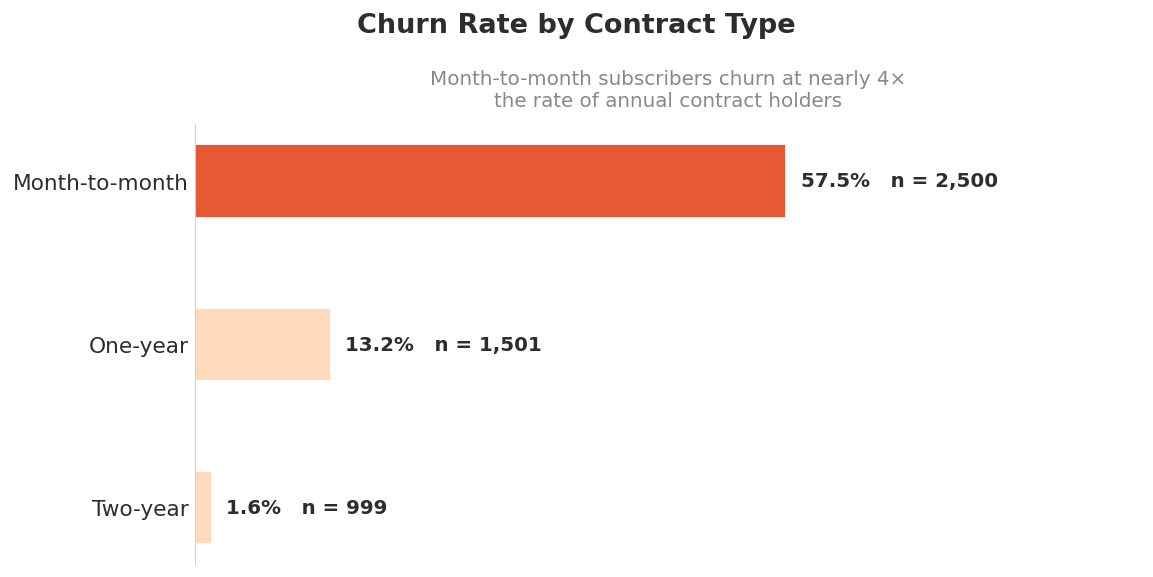

In [14]:
# Churn rate by contract type
churn_rate_barh(
    column   = "contract_type",
    title    = "Churn Rate by Contract Type",
    subtitle = "Month-to-month subscribers churn at nearly 4×\nthe rate of annual contract holders",
    filename = "plot_02_churn_by_contract.png",
)

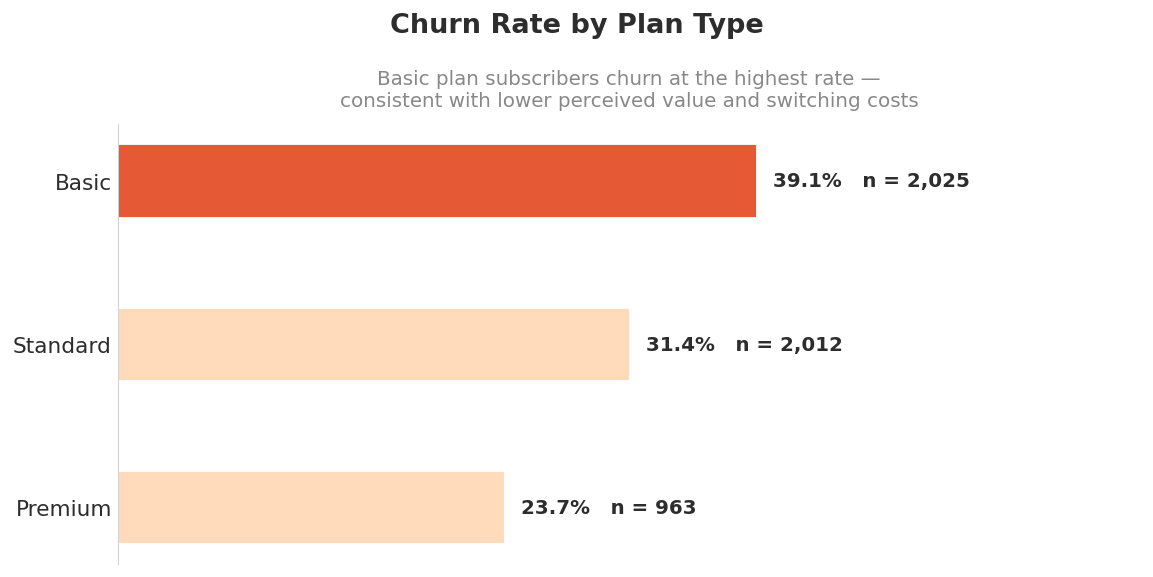

In [15]:
# Churn rate by plan type
churn_rate_barh(
    column   = "plan_type",
    title    = "Churn Rate by Plan Type",
    subtitle = "Basic plan subscribers churn at the highest rate —\nconsistent with lower perceived value and switching costs",
    filename = "plot_03_churn_by_plan.png",
)

In [16]:
# Violin plots helper
def violin_plot_styled(column, title, subtitle, ylabel, filename=None):
    # Remove outliers with IQR rule
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr     = q3 - q1
    clean   = df[
        (df[column] >= q1 - 1.5 * iqr) &
        (df[column] <= q3 + 1.5 * iqr)
    ].copy()
    clean["status"] = clean["churned"].map(LABEL_MAP)

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.violinplot(
        data=clean,
        x="status", y=column,
        order=["Active", "Churned"],
        hue="status",
        palette={"Active": MAIN, "Churned": ACCENT},
        legend=False,
        inner=None,       # custom median overlay below
        linewidth=1.5,
        ax=ax,
    )

    # Per-group: median dot + callout annotation
    for i, label in enumerate(["Active", "Churned"]):
        med = clean.loc[clean["status"] == label, column].median()

        ax.scatter(i, med, color=BG, s=70, zorder=5,
                   edgecolors=DARK, linewidths=2)

        ax.annotate(
            f"Median: {med:.1f}",
            xy=(i, med), xytext=(i + 0.44, med),
            va="center", ha="left",
            fontsize=10, color=DARK, fontweight="bold",
            arrowprops=dict(
                arrowstyle="-", color=MID, lw=0.9,
                shrinkA=8, shrinkB=4,
            ),
        )

    ax.set_xlim(-0.65, 2.1)
    ax.spines["left"].set_visible(False)
    ax.tick_params(left=False)
    ax.set_xlabel("", labelpad=0)
    ax.set_ylabel(ylabel, fontsize=12, labelpad=10)
    fig.suptitle(title,    fontsize=15, fontweight="bold", color=DARK)
    ax.set_title(subtitle, fontsize=11, color=MID, pad=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.45, color="#DDDDDD")
    ax.set_axisbelow(True)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

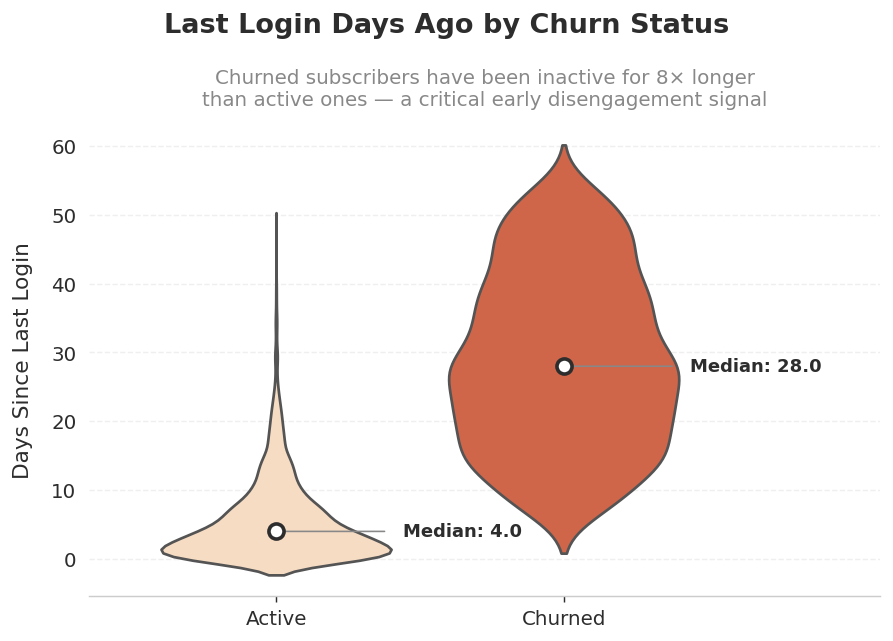

In [17]:
# Churn rate by the last login days signed
violin_plot_styled(
    column   = "last_login_days_ago",
    title    = "Last Login Days Ago by Churn Status",
    subtitle = "Churned subscribers have been inactive for 8× longer\nthan active ones — a critical early disengagement signal",
    ylabel   = "Days Since Last Login",
    filename = "plot_04_last_login.png",
)

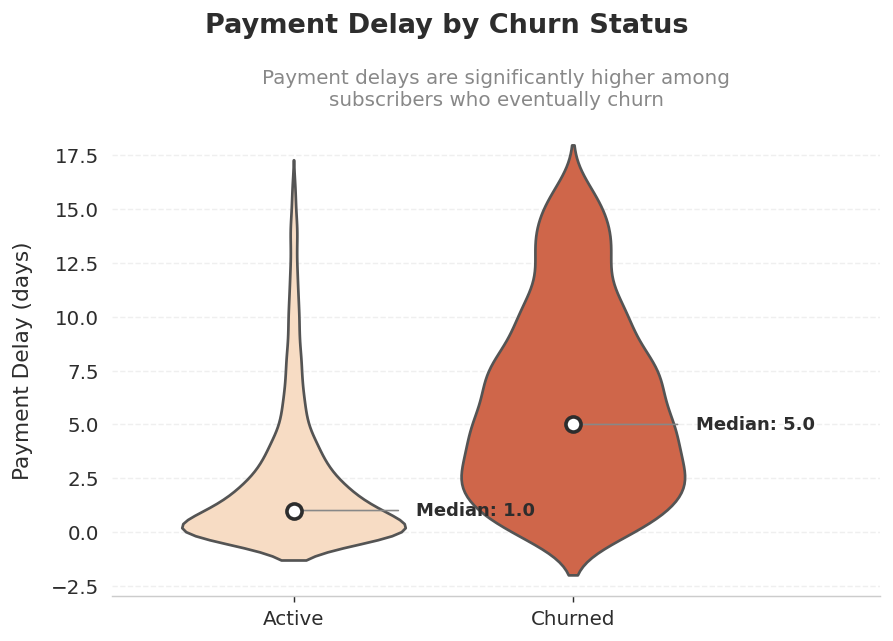

In [18]:
# Churn rate by payment delays by days
violin_plot_styled(
    column   = "payment_delay_days",
    title    = "Payment Delay by Churn Status",
    subtitle = "Payment delays are significantly higher among\nsubscribers who eventually churn",
    ylabel   = "Payment Delay (days)",
    filename = "plot_05_payment_delay.png",
)

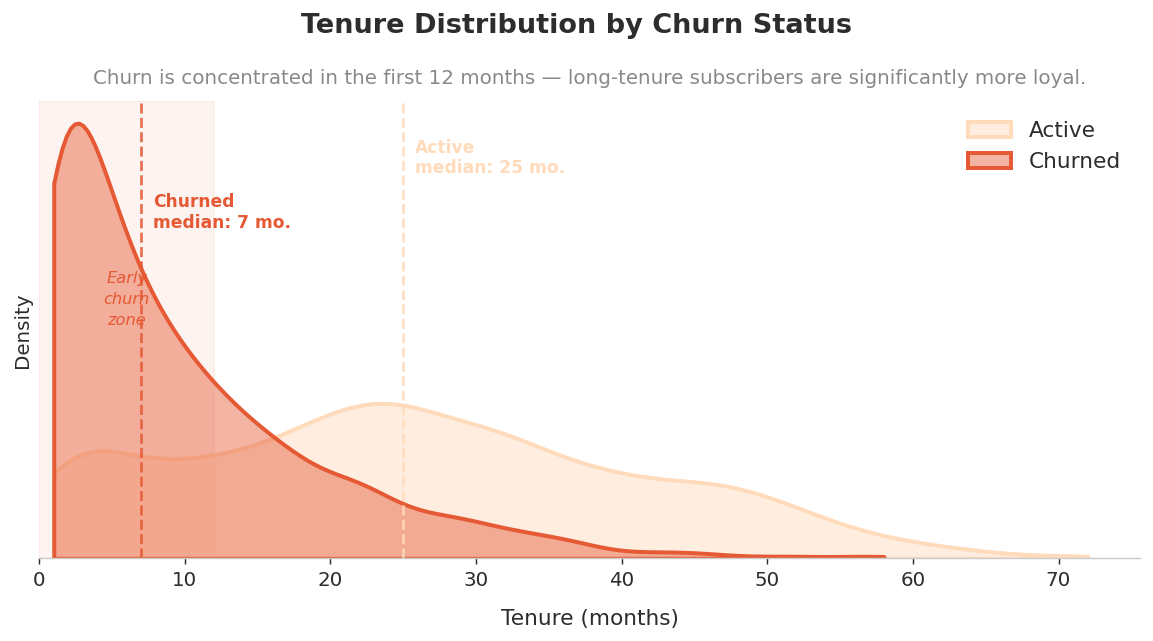

In [19]:
# Tenure distribution by churn status
fig, ax = plt.subplots(figsize=(9, 5))

groups = {
    "Active":  (df[df["churned"] == 0]["tenure_months"], MAIN),
    "Churned": (df[df["churned"] == 1]["tenure_months"], ACCENT),
}

for label, (data, color) in groups.items():
    sns.kdeplot(
        data, ax=ax,
        color=color, fill=True, alpha=0.45,
        linewidth=2.2, label=label, cut=0,
    )
    med = data.median()
    ax.axvline(med, color=color, linestyle="--", linewidth=1.5, alpha=0.85)
    ax.text(
        med + 0.8,
        0.80 if label == "Churned" else 0.92,
        f"{label}\nmedian: {med:.0f} mo.",
        color=color, fontsize=9.5, fontweight="bold", va="top",
        transform=ax.get_xaxis_transform(),
    )

# Subtle shading over the early-dropout window
ax.axvspan(0, 12, alpha=0.07, color=ACCENT, zorder=0)
ax.text(
    6, 0.63, "Early\nchurn\nzone",
    ha="center", va="top", fontsize=9, color=ACCENT,
    style="italic", linespacing=1.5,
    transform=ax.get_xaxis_transform(),
)

ax.set_xlabel("Tenure (months)", fontsize=12, labelpad=10)
ax.set_xlim(left=0)
ax.spines["left"].set_visible(False)
ax.set_yticks([])
ax.legend(frameon=False, fontsize=12, loc="upper right")
fig.suptitle("Tenure Distribution by Churn Status", fontsize=15, fontweight="bold", color=DARK)
ax.set_title("Churn is concentrated in the first 12 months — long-tenure subscribers are significantly more loyal.",
             fontsize=11, color=MID, pad=10)

plt.tight_layout()
plt.savefig("plot_06_tenure_distribution_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## Modeling

### Data Inspection

In [20]:
# Custom diverging colormap: steel blue → white → brand accent
cmap_corr = LinearSegmentedColormap.from_list(
    "voxtel_corr", ["#4575B4", "#FFFFFF", ACCENT]
)

MULTICOLLINEARITY_THRESHOLD = 0.5

In [21]:
# Correlation heatmap helper
def correlation_heatmap(corr_matrix, method_name, subtitle, filename=None):
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        corr_matrix, mask=mask,
        cmap=cmap_corr, vmin=-1, vmax=1, center=0,
        annot=True, fmt=".2f",
        annot_kws={"size": 9, "color": DARK},
        linewidths=0.5, linecolor="#EEEEEE",
        square=True,
        cbar_kws={"shrink": 0.75, "label": "Correlation coefficient"},
        ax=ax,
    )

    # Draw a border around every cell that exceeds the threshold
    for i in range(len(corr_matrix.columns)):
        for j in range(i):    # lower triangle only
            if abs(corr_matrix.iloc[i, j]) > MULTICOLLINEARITY_THRESHOLD:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=False, edgecolor=ACCENT, linewidth=2.5, zorder=3,
                ))

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    fig.suptitle(f"{method_name} Correlation Matrix",
                 fontsize=15, fontweight="bold", color=DARK)
    ax.set_title(subtitle, fontsize=11, color=MID, pad=10)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f"{filename}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [22]:
# Numeric features to inspect
numeric_data = df.select_dtypes(include=np.number).drop(["has_streaming_addon", "churned"], axis=1)
numeric_data.columns

Index(['tenure_months', 'monthly_charges', 'total_charges',
       'payment_delay_days', 'data_usage_gb', 'num_support_tickets',
       'last_login_days_ago', 'clv_estimated'],
      dtype='object')

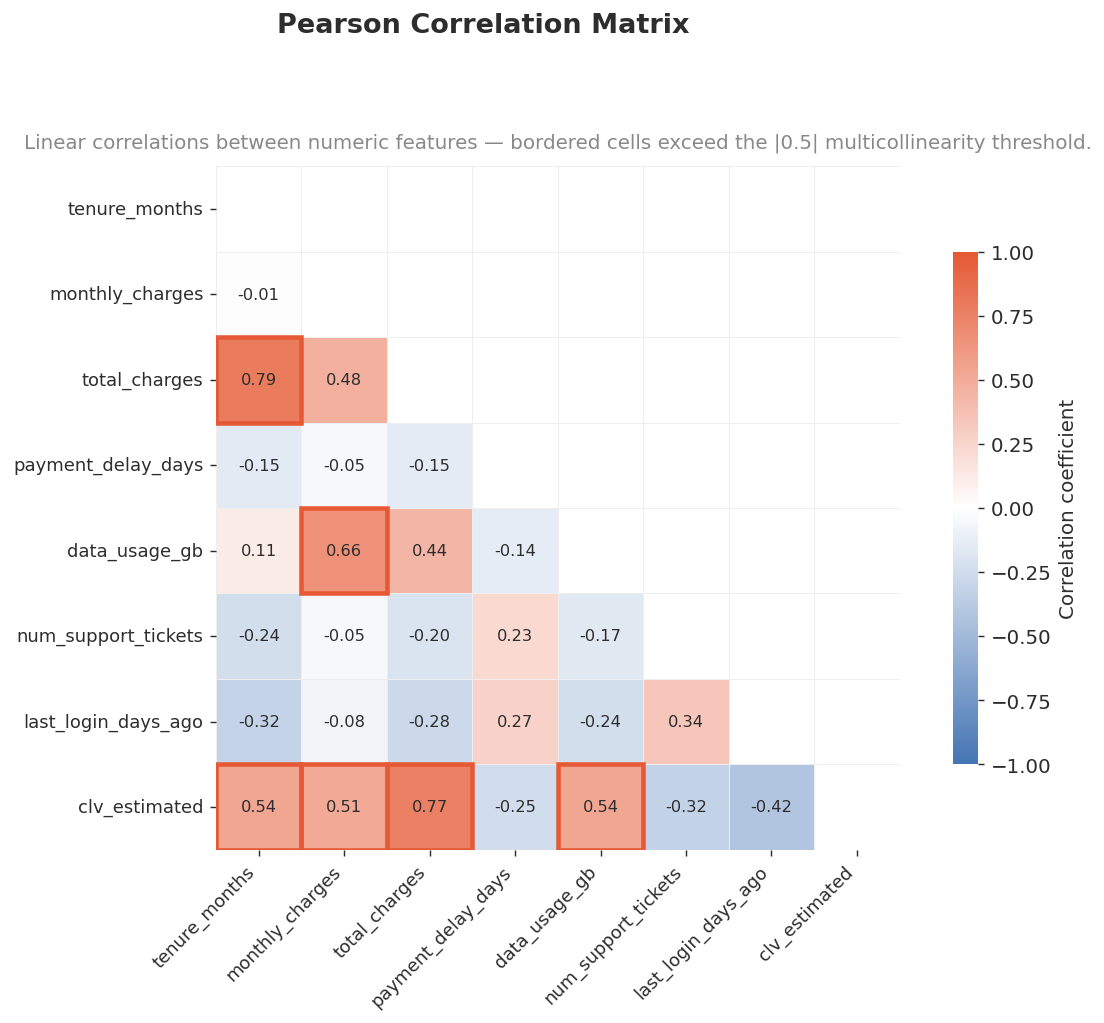

In [23]:
# Pearson
correlation_heatmap(
    corr_matrix = numeric_data.corr(),
    method_name = "Pearson",
    subtitle    = "Linear correlations between numeric features — bordered cells exceed the |0.5| multicollinearity threshold.",
    filename    = "plot_07_pearson",
)

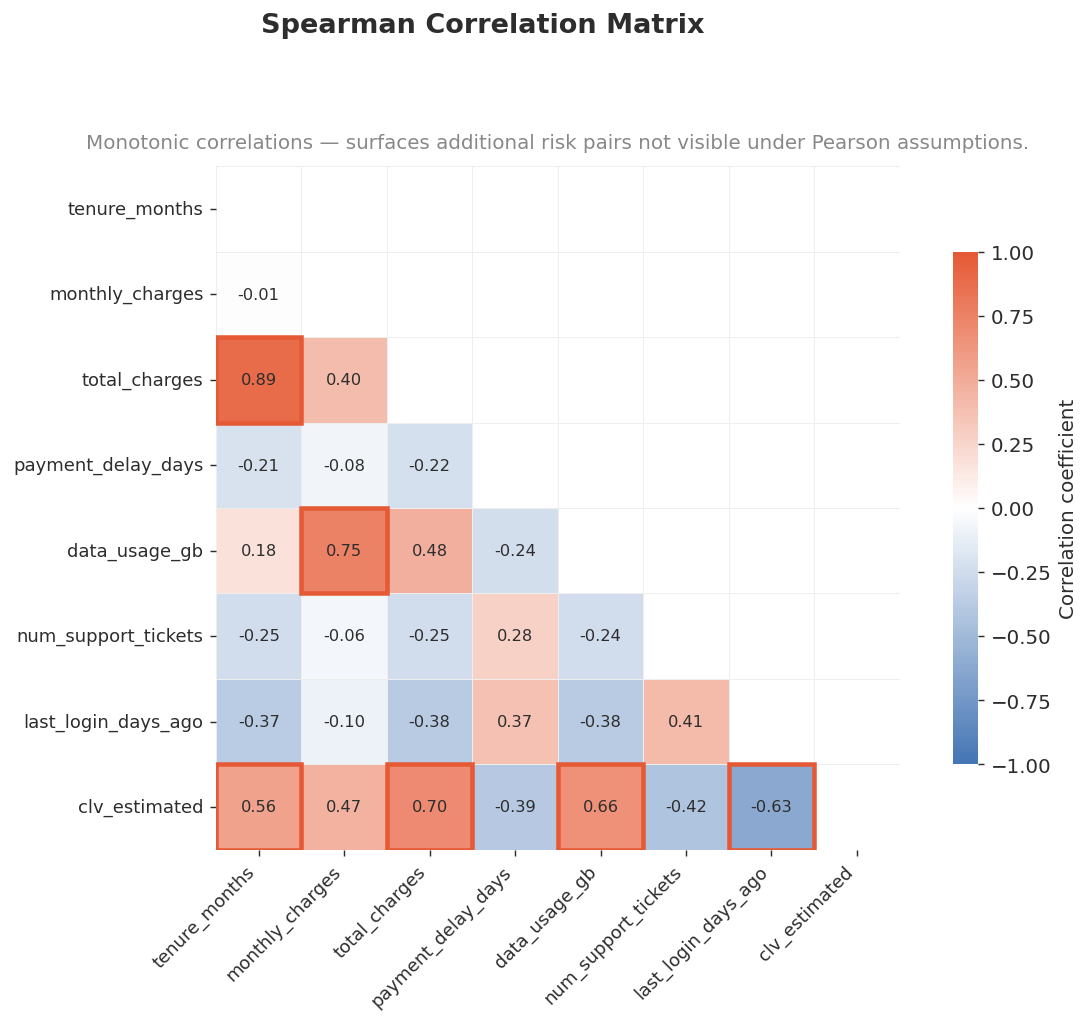

In [24]:
# Spearman
correlation_heatmap(
    corr_matrix = numeric_data.corr(method="spearman"),
    method_name = "Spearman",
    subtitle    = "Monotonic correlations — surfaces additional risk pairs not visible under Pearson assumptions.",
    filename    = "plot_08_spearman",
)

In [25]:
# Categoric inspection
categoric_data = df.select_dtypes(exclude=np.number)
categoric_data[["has_streaming_addon", "churned"]] = df[["has_streaming_addon", "churned"]]
categoric_data.columns

Index(['customer_id', 'contract_type', 'plan_type', 'payment_method',
       'has_streaming_addon', 'churned'],
      dtype='object')

In [26]:
# V Cramer and Chi square correlation tests
def categoric_correlation(column1, column2):
  cross_table = pd.crosstab(df[column1], df[column2])
  v_cramer = association(cross_table)
  chi2, p, dof, expected = chi2_contingency(cross_table)
  print(f"Correlation between {column1}, {column2}\nV Cramer: {v_cramer:.2f}\nChi square p-value: {p:.2f}")

In [27]:
# Categorical predictor features (excluding 'customer_id' and 'churned')
categorical_predictors = [col for col in categoric_data.columns if col not in ['customer_id', 'churned']]

# Generate all unique pairs of categorical predictor features
pairwise_combinations = list(combinations(categorical_predictors, 2))

print("Evaluating pairwise correlations between categorical predictor features for multicollinearity:")
for col1, col2 in pairwise_combinations:
    categoric_correlation(col1, col2)
    print("\n")

Evaluating pairwise correlations between categorical predictor features for multicollinearity:
Correlation between contract_type, plan_type
V Cramer: 0.03
Chi square p-value: 0.17


Correlation between contract_type, payment_method
V Cramer: 0.01
Chi square p-value: 0.92


Correlation between contract_type, has_streaming_addon
V Cramer: 0.01
Chi square p-value: 0.75


Correlation between plan_type, payment_method
V Cramer: 0.02
Chi square p-value: 0.59


Correlation between plan_type, has_streaming_addon
V Cramer: 0.53
Chi square p-value: 0.00


Correlation between payment_method, has_streaming_addon
V Cramer: 0.02
Chi square p-value: 0.56




### Data preparation and setup

In [28]:
# Hyperparameters
SEED = 42

DROP_COLS = [
    "churned",             # Target feature
    "customer_id",         # Id, not important
    "total_charges",       # High correlation with tenure months; tenure is more useful
    "clv_estimated",       # High correlation with several features; useful just for ROI and KPIs showcase
    "has_streaming_addon", # High correlation between plan type; plan type is more descriptive
    "tenure_months",       # The model had been run, and this feature doesn't improve performance
    "payment_method",      # The model had been run, and this feature doesn't improve performance
    "monthly_charges"      # The model had been run, and this feature doesn't improve performance
    ]

PARAM_GRID = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag"]
}

In [29]:
# Features and target
X = df.drop(DROP_COLS, axis=1)
y = df.churned

In [30]:
# Train / test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

In [31]:
# Numeric and categoric features
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(exclude=np.number).columns

### Preprocessing

In [32]:
# Imputers
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

In [33]:
# Scaler
scaler = RobustScaler()

In [34]:
# One Hot Encoder
encoder = OneHotEncoder()

In [35]:
# Numeric preprocessor
num_pipe = Pipeline(steps=[
    ("num_imputer", num_imputer),
    ("scaler", scaler)
])

# Categoric preprocessor
cat_pipe = Pipeline(steps=[
    ("cat_imputer", cat_imputer),
    ("encoder", encoder)
])

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num_pipe", num_pipe, num_cols),
    ("cat_pipe", cat_pipe, cat_cols)
])

### Baseline model

In [36]:
# Style plots setup
def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(left=False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.45, color="#DDDDDD")
    ax.set_axisbelow(True)

def insight_title(ax, title, subtitle=""):
    ax.annotate(
        title,
        xy=(0, 1), xycoords="axes fraction",
        xytext=(0, 30), textcoords="offset points",
        fontsize=13, fontweight="bold", color=TEXT,
        va="bottom", ha="left", annotation_clip=False,
    )
    ax.set_title(subtitle, fontsize=10, color=MID, pad=12, loc="left")

def style_axis_h(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(left=False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.45, color="#DDDDDD")
    ax.set_axisbelow(True)

In [37]:
# Evaluation report
def evaluation(y_test, y_pred, y_proba):
    """
    Binary classification evaluation: metrics + 3 diagnostic plots.

    Assumes y_proba[:, 1] = P(Churned) — standard sklearn predict_proba output.

    Metrics:
      Accuracy | Precision | Recall | F1   (classification report)
      ROC AUC score

    Plots:
      [1] Confusion matrix   — row-normalised, count + % per cell
      [2] ROC AUC curve      — with shaded area and random baseline
      [3] Precision-Recall   — with random baseline
    """
    CLASS_LABELS = ["Active", "Churned"]
    cmap_cm      = mcolors.LinearSegmentedColormap.from_list("voxtel", [MAIN, ACCENT])

    # ── Metrics ───────────────────────────────────────────────────────────────
    print(metrics.classification_report(
        y_test, y_pred,
        target_names=CLASS_LABELS, labels=[0, 1],
    ))

    ras = metrics.roc_auc_score(y_test, y_proba[:, 1])
    print(f"\nROC AUC score: {ras:.4f}\n")

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(9, 16))
    fig.patch.set_facecolor(BG)

    # ── [1] Confusion Matrix ──────────────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor(BG)

    cm     = metrics.confusion_matrix(y_test, y_pred, labels=[0, 1])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im     = ax.imshow(cm_pct, cmap=cmap_cm, vmin=0, vmax=100, aspect="auto")

    for i in range(2):
        for j in range(2):
            pct = cm_pct[i, j]
            ax.text(j, i, f"{cm[i, j]:,}\n({pct:.1f}%)",
                    ha="center", va="center", fontsize=12, fontweight="bold",
                    color="white" if pct > 55 else TEXT)

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_LABELS); ax.set_yticklabels(CLASS_LABELS)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.tick_params(length=0)
    for sp in ax.spines.values(): sp.set_visible(False)

    cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
    cbar.set_label("% recalled per true class", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    insight_title(ax, "Confusion Matrix",
                  "Diagonal = correctly identified;  off-diagonal = misclassified subscribers")

    # ── [2] ROC AUC Curve ─────────────────────────────────────────────────────
    ax = axes[1]
    ax.set_facecolor(BG)

    fpr, tpr, _ = metrics.roc_curve(y_test, y_proba[:, 1])
    auc_val     = metrics.auc(fpr, tpr)

    ax.plot([0, 1], [0, 1], "--", color="#C4B8AE", linewidth=1.3,
            label="Random  (AUC = 0.50)")
    ax.fill_between([0, 1], [0, 1], alpha=0.05, color="#C4B8AE")

    ax.plot(fpr, tpr, color=ACCENT, linewidth=2.6,
            label=f"Churned  (AUC = {auc_val:.2f})")
    ax.fill_between(fpr, tpr, alpha=0.09, color=ACCENT)

    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_xlim([-0.01, 1.0]); ax.set_ylim([0, 1.04])
    ax.legend(frameon=False, fontsize=10, loc="lower right")
    insight_title(ax, "ROC AUC Curve",
                  f"AUC = {auc_val:.2f}  —  measures separation between churners and active subscribers")
    style_axis(ax)

    # ── [3] Precision-Recall Curve ────────────────────────────────────────────
    ax = axes[2]
    ax.set_facecolor(BG)

    prec, rec, _ = metrics.precision_recall_curve(y_test, y_proba[:, 1])
    ap           = metrics.average_precision_score(y_test, y_proba[:, 1])
    baseline     = y_test.mean()

    ax.plot(rec, prec, color=ACCENT, linewidth=2.6,
            label=f"Churned  (AP = {ap:.2f})")
    ax.fill_between(rec, prec, alpha=0.09, color=ACCENT)
    ax.axhline(baseline, linestyle=":", linewidth=1.4, color=ACCENT, alpha=0.55,
               label=f"Random baseline  ({baseline:.2f})")

    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim([0, 1.01]); ax.set_ylim([0, 1.05])
    ax.legend(frameon=False, fontsize=10, loc="upper right")
    insight_title(ax, "Precision-Recall Curve",
                  "Dotted line = random baseline;  area above = predictive signal beyond chance")
    style_axis(ax)

    fig.suptitle(f"Model Evaluation  —  {len(y_test):,} test samples",
                 y=1.01, fontsize=14, fontweight="bold", color=TEXT)
    plt.tight_layout()
    plt.show()

              precision    recall  f1-score   support

      Active       0.67      1.00      0.80       670
     Churned       0.00      0.00      0.00       330

    accuracy                           0.67      1000
   macro avg       0.34      0.50      0.40      1000
weighted avg       0.45      0.67      0.54      1000


ROC AUC score: 0.5000



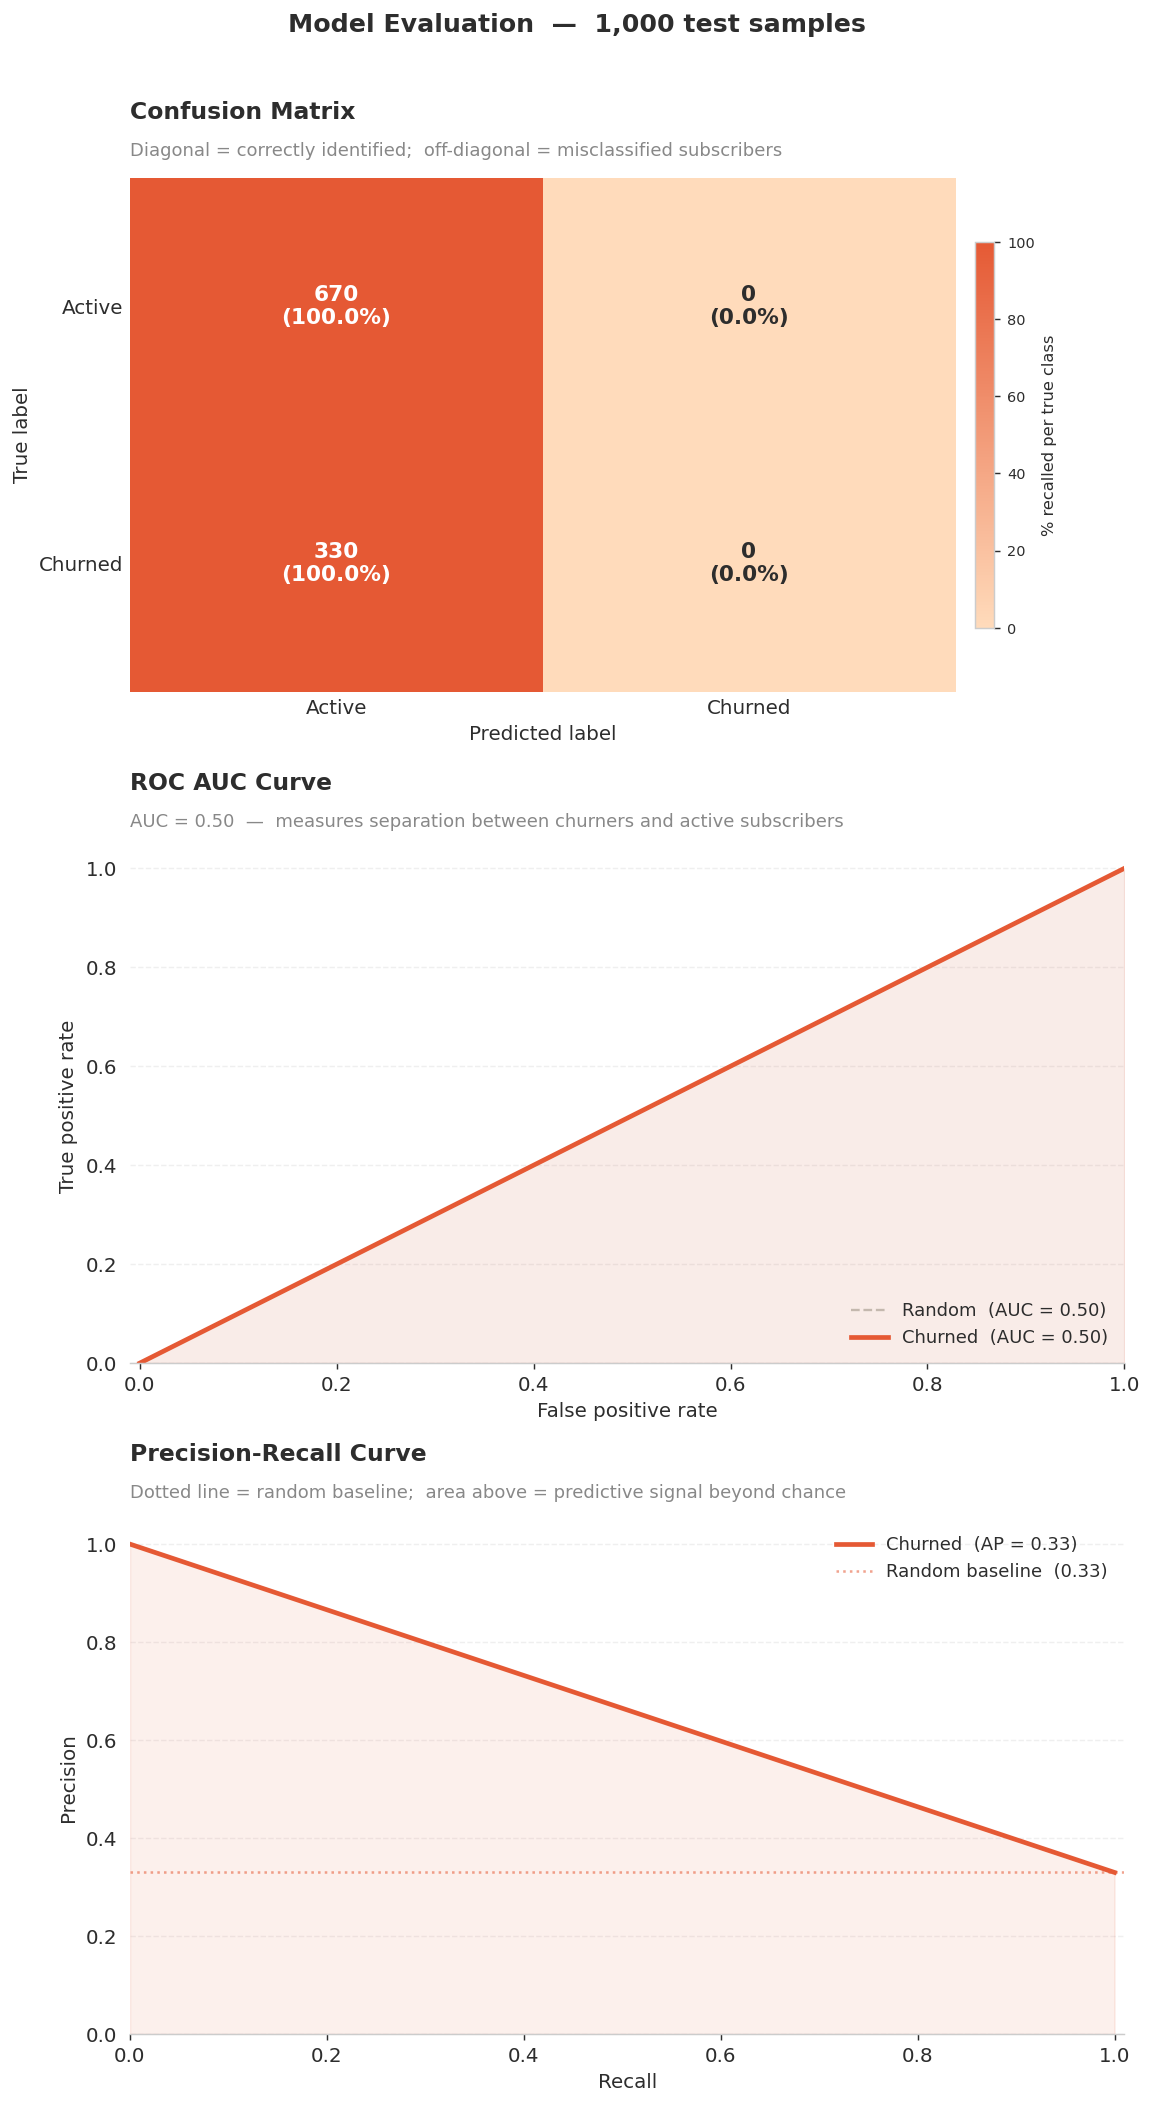

In [38]:
# Baseline model
dummy = DummyClassifier(random_state=SEED)
pipe_dummy = Pipeline(steps=[("preprocessor", preprocessor), ("dummy", dummy)])

# Dummy fit
pipe_dummy.fit(X_train, y_train)

# Predictions
y_dummy = pipe_dummy.predict(X_test)
y_dummy_proba = pipe_dummy.predict_proba(X_test)

# Dummy evaluations
evaluation(y_test, y_dummy, y_dummy_proba)

### Model definintion

In [39]:
# Defining model
lr = LogisticRegression(penalty="l2", class_weight="balanced", random_state=SEED)

In [40]:
# Creating pipeline
pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", lr)])

In [41]:
# Creating Folds
cv = StratifiedKFold(n_splits=5)

In [42]:
# Hiperparametrization
grid = GridSearchCV(pipe, param_grid=PARAM_GRID, scoring="f1", n_jobs=-1, cv=cv)

### Training

In [43]:
# Training the model
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num_pipe',
                                                                         Pipeline(steps=[('num_imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         Index(['payment_delay_days', 'data_usage_gb', 'num_support_tickets',
       'last_login_days_ago'],
      dtype=...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder())]),
                                                                         Index(['contract_type', 'plan_type'], dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__solver': ['lbfgs', 'liblinear',
                                                'newton-cg', 'newton-cholesky',
                                                'sag']},
             scoring='f1')

In [44]:
# Best score and parameters found
print(f"Best F1-score: {grid.best_score_:.2f}")
print(f"Best parameters:\n{grid.best_params_}")

Best F1-score: 0.95
Best parameters:
{'classifier__C': 100, 'classifier__solver': 'lbfgs'}


In [45]:
# Predictions
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)

## Evaluation and Explainability

              precision    recall  f1-score   support

      Active       0.98      0.96      0.97       670
     Churned       0.92      0.97      0.95       330

    accuracy                           0.96      1000
   macro avg       0.95      0.97      0.96      1000
weighted avg       0.96      0.96      0.96      1000


ROC AUC score: 0.9941



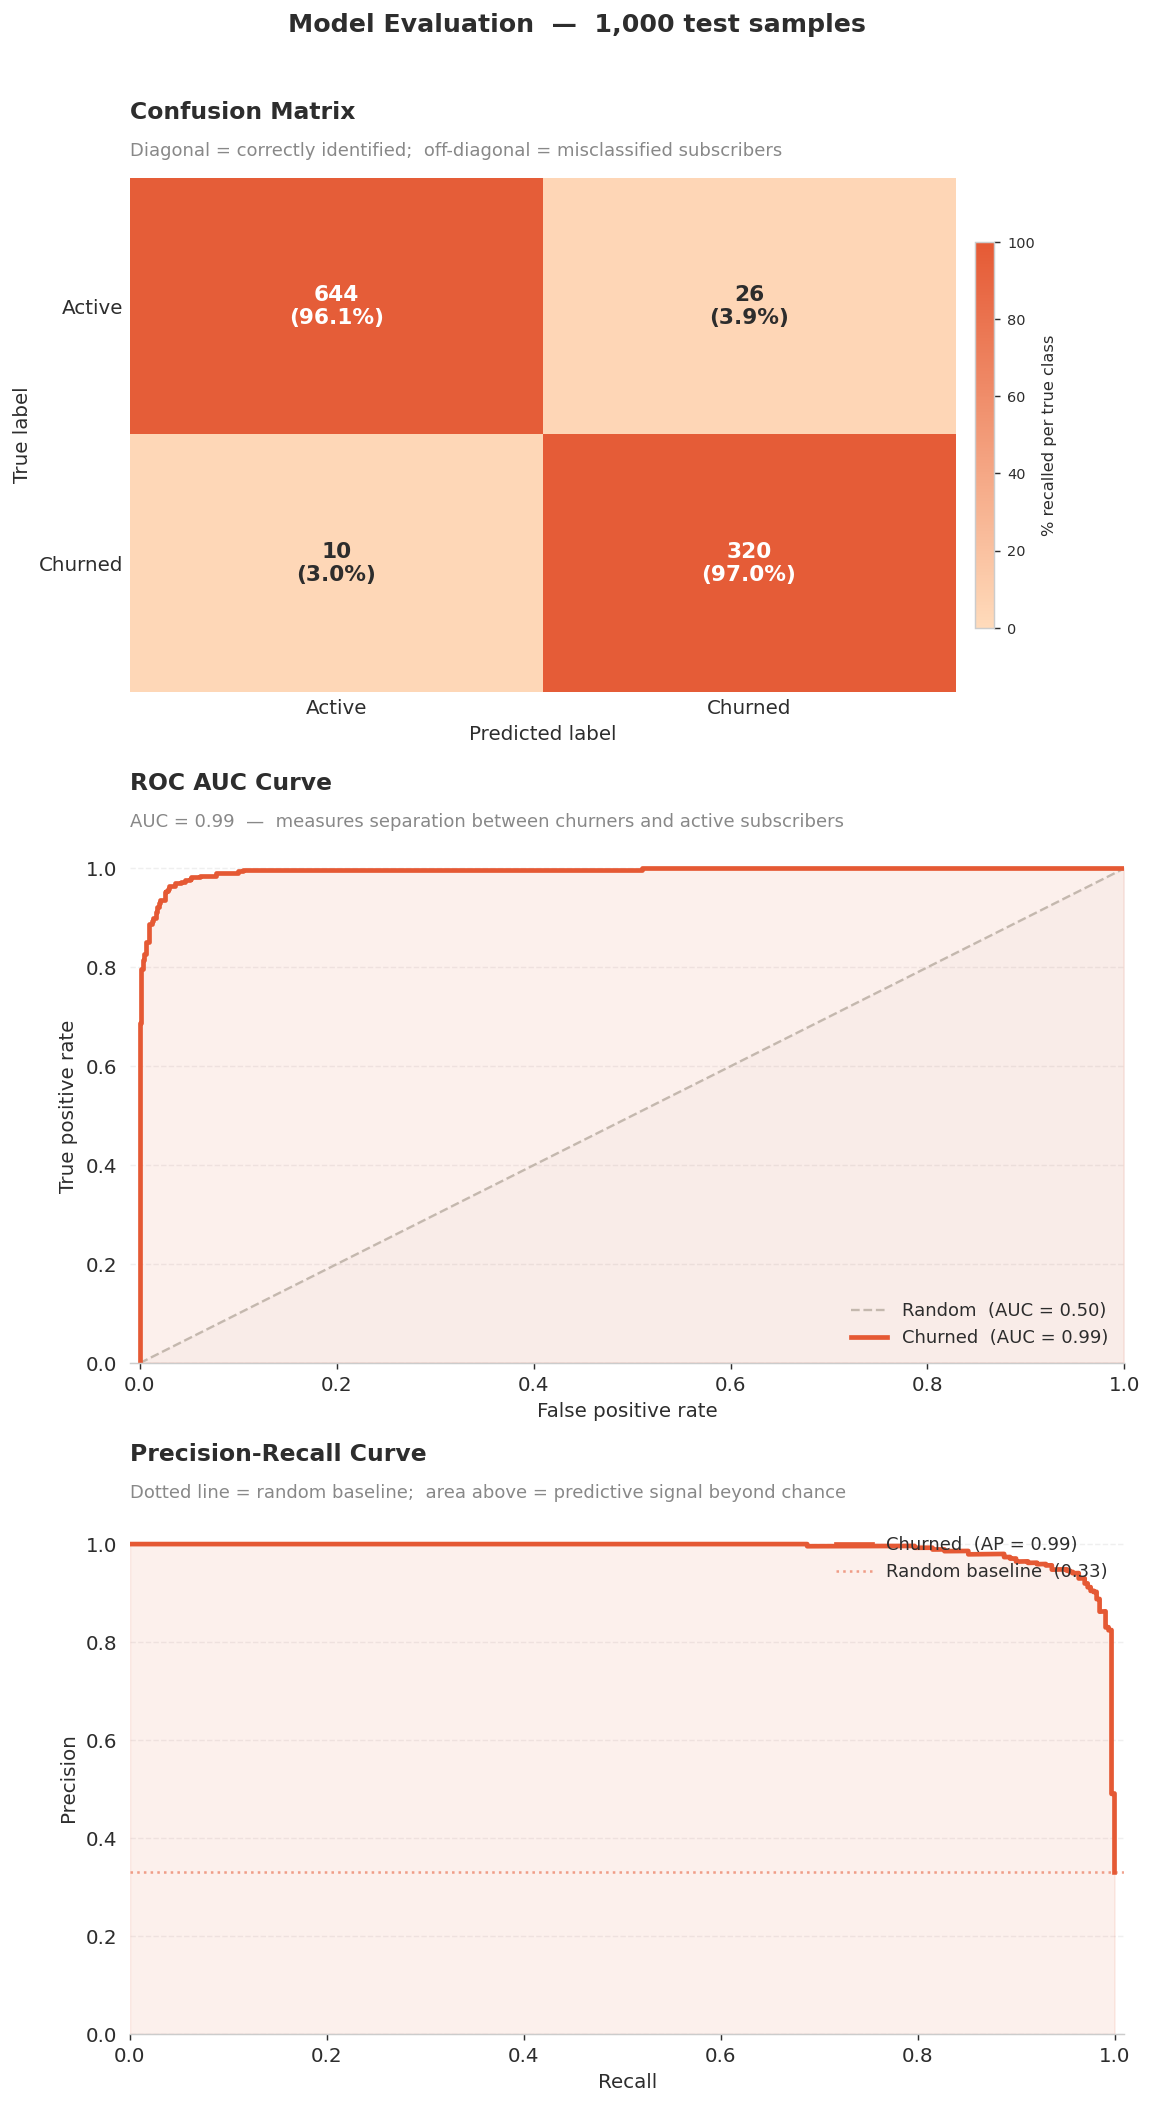

In [46]:
# Evaluation report
evaluation(y_test, y_pred, y_proba)

In [47]:
# Cross validation test
scores = cross_val_score(grid, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

print("Scores:", scores)
print("Average scores:", scores.mean())

Scores: [0.93831776 0.93900185 0.96616541 0.95009242 0.96296296]
Average scores: 0.9513080806753507


In [48]:
def plot_permutation_importance(grid, X_test, y_test, filename, n_repeats=10, random_state=42):
    """
    Computes and plots permutation feature importance for a fitted pipeline.

    Permutation importance shuffles each raw input feature (before preprocessing)
    and measures the resulting drop in ROC AUC. One importance score is returned
    per original input column — not per OHE dummy — which makes it more readable.

    Parameters
    ----------
    grid         : fitted Pipeline or GridSearchCV
                   If GridSearchCV, best_estimator_ is extracted automatically.
    X_test       : pd.DataFrame — raw (unprocessed) test features
    y_test       : pd.Series   — true binary labels
    n_repeats    : int — shuffles per feature; more = more stable, slower (default 10)
    random_state : int
    """
    model             = grid.best_estimator_
    raw_feature_names = X_test.columns.tolist()

    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring="roc_auc",
    )

    imp_df = (pd.DataFrame({
                  "feature":    raw_feature_names,
                  "importance": result.importances_mean,
                  "std":        result.importances_std,
              })
              .sort_values("importance", ascending=True))

    colors = [ACCENT if v == imp_df["importance"].max() else MAIN
              for v in imp_df["importance"]]

    fig, ax = plt.subplots(figsize=(9, max(5, len(imp_df) * 0.6)))
    fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

    ax.barh(imp_df["feature"], imp_df["importance"],
            xerr=imp_df["std"], color=colors,
            edgecolor=BG, height=0.6,
            error_kw={"elinewidth": 1.2, "ecolor": TEXT, "capsize": 3})
    ax.axvline(0, color=TEXT, linewidth=0.8, linestyle="--", alpha=0.5)

    style_axis_h(ax)
    ax.set_xlabel("Mean decrease in ROC AUC when feature is randomly shuffled", fontsize=10)
    insight_title(ax, "Permutation Feature Importance",
                  "Error bars show variability across shuffles. Negative values mean the feature adds noise.")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    if filename:
      plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

In [49]:
def plot_shap(grid, X_train, top_n=15):
    """
    Computes SHAP values and renders two explainability plots:
      [1] Mean |SHAP| bar chart  — global feature ranking
      [2] Beeswarm               — direction and distribution of each feature's impact

    SHAP is computed on X_train (the distribution the model learned from).
    Because OHE expands categorical columns into dummies, importance scores
    are returned at the dummy level — the feature names here reflect that.

    Compatible with both legacy (list of arrays) and new (3D array) shap output
    formats across different shap versions and model types.

    Parameters
    ----------
    grid    : fitted Pipeline or GridSearchCV
              If GridSearchCV, best_estimator_ is extracted automatically.
    X_train : pd.DataFrame — raw training features (preprocessor applied internally)
    top_n   : int — features to display, sorted by mean |SHAP| (default 15)
    """
    model         = grid.best_estimator_
    X_transformed = model.named_steps["preprocessor"].transform(X_train)

    # Reconstruct feature names after OHE expansion
    cat_cols_ = model.named_steps["preprocessor"].transformers_[1][2]
    num_cols_ = model.named_steps["preprocessor"].transformers_[0][2]
    ohe_cols_ = (model.named_steps["preprocessor"]
                      .named_transformers_["cat_pipe"]
                      .get_feature_names_out(cat_cols_).tolist())
    feat_names = list(num_cols_) + ohe_cols_

    # LinearExplainer: native support for Linear Regression, Lasso Regression, Logistic Regression
    explainer   = shap.LinearExplainer(model.named_steps["classifier"], masker=X_transformed)
    shap_values = explainer.shap_values(X_transformed)

    # Normalise to 2D array of P(Churned) regardless of shap version:
    # · older shap  → list of 2 arrays (n_samples, n_features); take index 1
    # · newer shap  → single 3D array (n_samples, n_features, n_classes); take [:, :, 1]
    if isinstance(shap_values, list):
        sv = shap_values[1]
    elif shap_values.ndim == 3:
        sv = shap_values[:, :, 1]
    else:
        sv = shap_values    # already 2D (e.g. XGBoost binary output)

    shap_df   = pd.DataFrame(sv, columns=feat_names)
    mean_abs  = shap_df.abs().mean().sort_values(ascending=True).tail(top_n)
    top_feats = mean_abs.index.tolist()

    # ── [1] Bar chart ─────────────────────────────────────────────────────────
    colors = [ACCENT if v == mean_abs.max() else MAIN for v in mean_abs]

    fig, ax = plt.subplots(figsize=(9, max(5, top_n * 0.6)))
    fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

    ax.barh(mean_abs.index, mean_abs.values, color=colors, edgecolor=BG, height=0.6)
    style_axis_h(ax)
    ax.set_xlabel("Mean |SHAP value|  —  average magnitude of impact on churn prediction", fontsize=10)
    insight_title(ax, "SHAP Feature Importance",
                  "Higher mean |SHAP| = stronger average contribution to the model output, regardless of direction.")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    # ── [2] Beeswarm ──────────────────────────────────────────────────────────
    top_idx     = [feat_names.index(f) for f in top_feats]
    voxtel_cmap = mcolors.LinearSegmentedColormap.from_list("voxtel_shap", [MAIN, ACCENT])

    explanation = shap.Explanation(
        values        = sv[:, top_idx],
        data          = X_transformed[:, top_idx],
        feature_names = top_feats,
    )

    shap.plots.beeswarm(explanation, max_display=top_n, color=voxtel_cmap, show=False)

    fig = plt.gcf(); fig.patch.set_facecolor(BG)
    ax  = fig.axes[0]; ax.set_facecolor(BG)
    ax.annotate("SHAP Beeswarm — Feature Impact Distribution",
        xy=(0, 1), xycoords="axes fraction",
        xytext=(0, 30), textcoords="offset points",
        fontsize=13, fontweight="bold", color=TEXT,
        va="bottom", ha="left", annotation_clip=False)
    ax.set_title(
        "Each dot = one subscriber. Colour = feature value (orange = high, peach = low). "
        "Position on x = impact on churn probability.",
        fontsize=10, color=MID, pad=12, loc="left")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

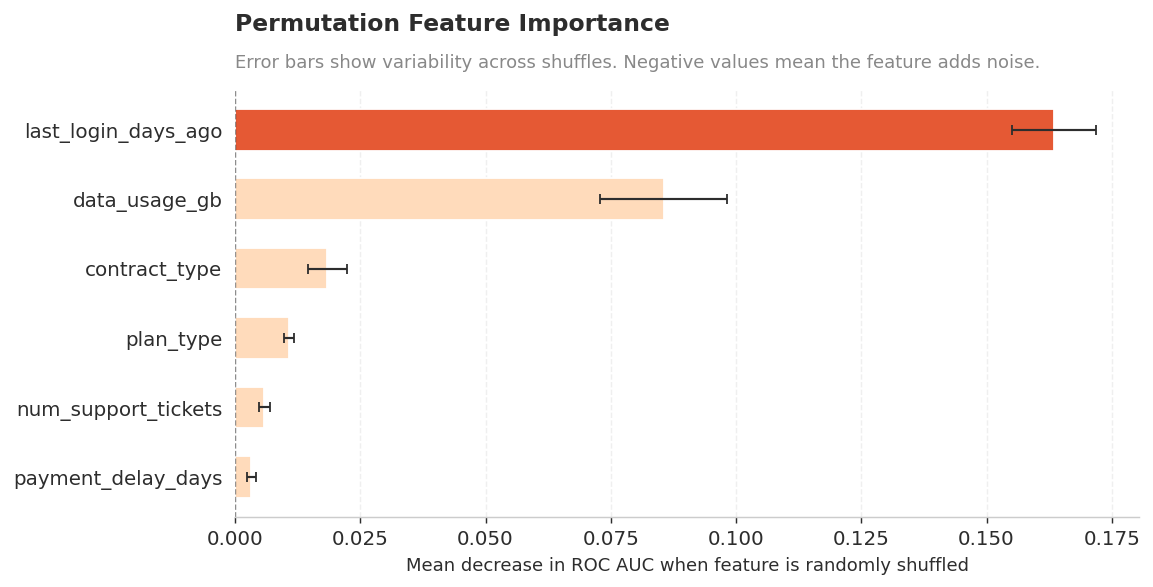

In [50]:
# Call
plot_permutation_importance(grid, X_test, y_test, filename="plot_09_perm_importance_check.png")

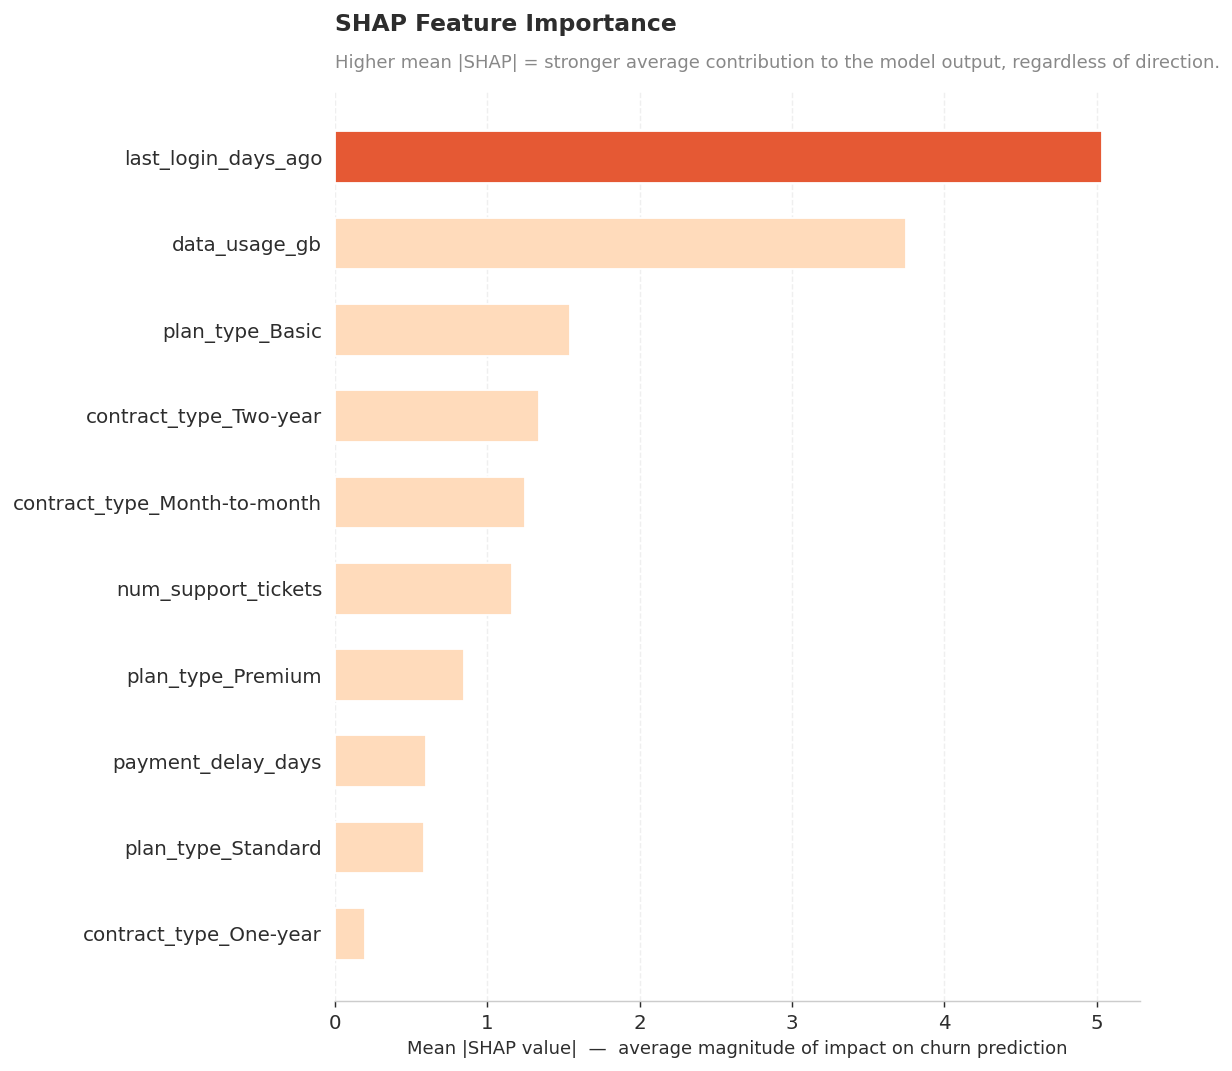

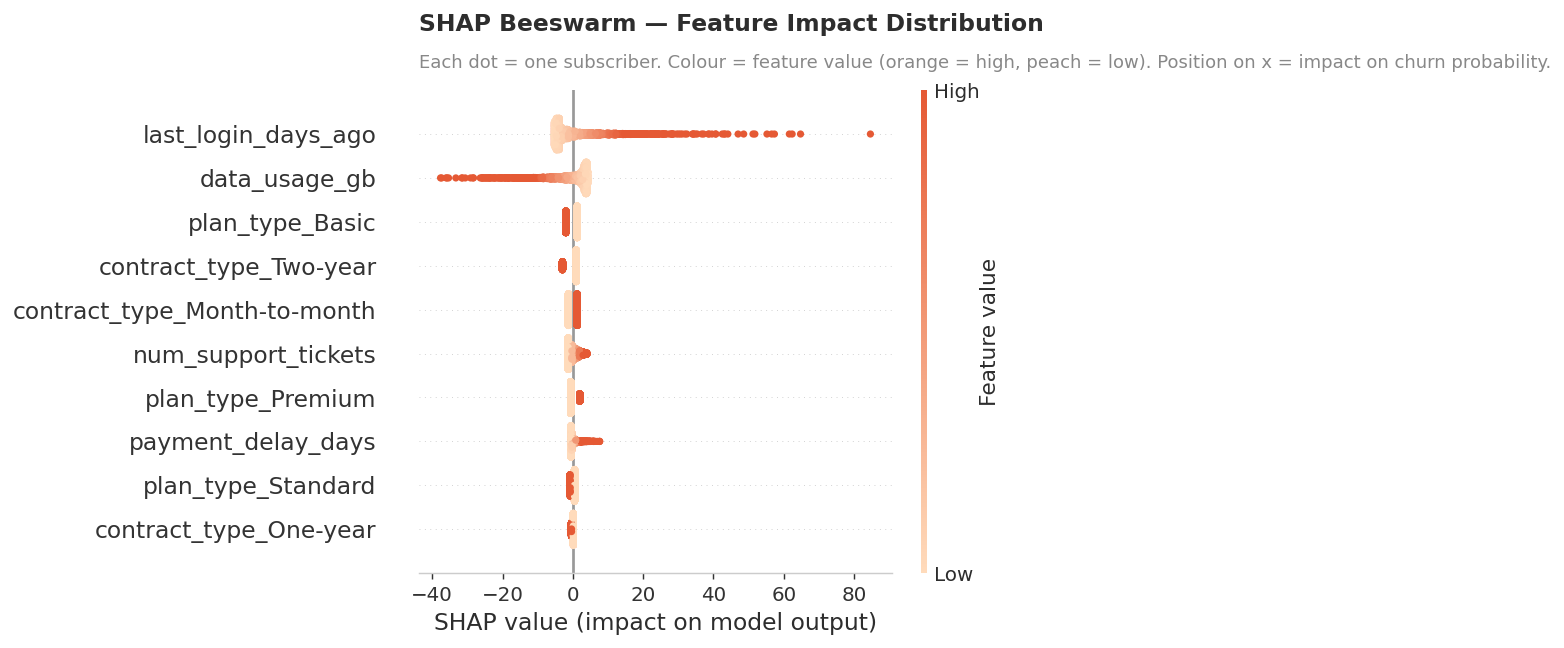

In [51]:
# Call
plot_shap(grid, X_train)

## Deployment

In [52]:
# Serializing the champion model
with open("champion.pkl", "wb") as f:
  pickle.dump(grid, f, protocol=-1)

print("Model dumped successfully")

Model dumped successfully


In [53]:
# Checkout the serialization
with open("champion.pkl", "rb") as f:
  champion = pickle.load(f)

champion

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num_pipe',
                                                                         Pipeline(steps=[('num_imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         Index(['payment_delay_days', 'data_usage_gb', 'num_support_tickets',
       'last_login_days_ago'],
      dtype=...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder())]),
                                                                         Index(['contract_type', 'plan_type'], dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__solver': ['lbfgs', 'liblinear',
                                                'newton-cg', 'newton-cholesky',
                                                'sag']},
             scoring='f1')